In [66]:
import pandas as pd

df =pd.read_parquet("data.parquet")

## Conversion des types

In [67]:
# domaine_etude => qualitative nominale
# get_dummies drop automatiquement ["domaine_etude"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["domaine_etude"], drop_first=True)

In [68]:
# statut_marital => qualitative nominale
# get_dummies drop automatiquement ["statut_marital"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["statut_marital"], drop_first=True)


In [69]:
# departement => qualitative nominale
# get_dummies drop automatiquement ["departement"]
# drop_first = Supprime la 1er catégorie (Commercial) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["departement"], drop_first=True)


In [70]:
# poste => qualitative nominale
# get_dummies drop automatiquement ["poste"]
# drop_first = Supprime la 1er catégorie (Assistant) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["poste"], drop_first=True)

In [71]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,bool
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,frequence_deplacement,int64
6,annees_depuis_la_derniere_promotion,int64
7,annes_sous_responsable_actuel,int64
8,age,int64
9,revenu_mensuel,int64


# corrélation de Pearson

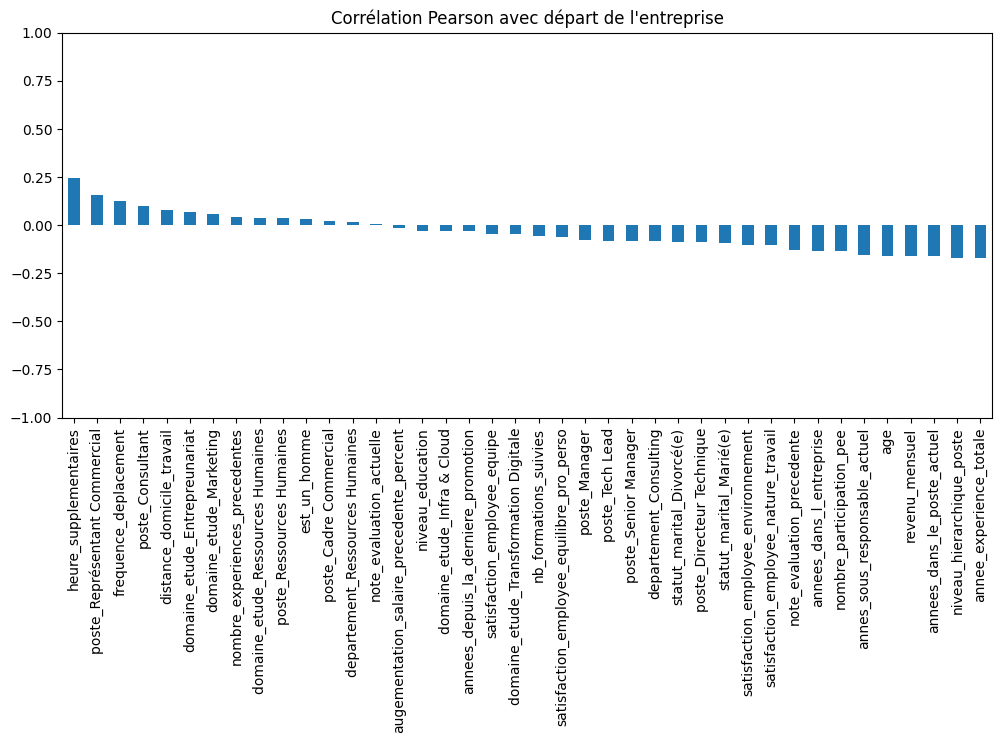

In [72]:
import matplotlib.pyplot as plt

df["a_quitte_l_entreprise"] = df["a_quitte_l_entreprise"].astype(int)

target_corr = df.corr(numeric_only=True)["a_quitte_l_entreprise"].sort_values(ascending=False)

target_corr.drop("a_quitte_l_entreprise").plot(kind="bar", figsize=(12,5))
plt.title("Corrélation Pearson avec départ de l'entreprise")
plt.ylim(-1, 1)
plt.show()

# séparation train/test

In [73]:
def separation_train_test():
    global X, y, X_train, X_test, y_train, y_test

    X = df.drop(columns=['a_quitte_l_entreprise'])
    y = df['a_quitte_l_entreprise']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
    print(f"Taille du jeu de test : {X_test.shape[0]} lignes")


# choix de l’algorithme (régression, classification, clustering…)

Ici on cherche à prédire le départ ou non d'un salarié, il s'agit d'une classification binaire.

Nous allons tester les modèles suivants en parallèle

* Régression logistique (LogisticRegression)
* Arbres de décision (DecisionTreeClassifier)
* Forêts aléatoires (RandomForestClassifier)
* Gradient Boosting (XGBoost **, LightGBM, CatBoost, GradientBoostingClassifier)


Points importants:
* Nous privilégions le recall pour minimiser les faux-négatifs par rapport aux faux-positifs car nous estimons qu'il est important de ne pas louper un salarié démissionaire

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

def entrainement_model(model_name: str, params, pred_test = True):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test, threshold


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    # Entraînement
    model.fit(X_train, y_train)

    if pred_test == True:

        # Prédictions
        y_pred = model.predict(X_test)
        
        # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
        y_proba = model.predict_proba(X_test)[:, 1]

        # ajuste les prédictions en fonction du seuil de probabilité
        y_pred = (y_proba >= threshold)

        # validation croisée stratifié
        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        scores = cross_val_score(
            model,
            X_test,
            y_test,
            cv=cv,
            scoring="recall"
        )
    
        # évaluation des performances (accuracy, RMSE, F1, etc.)
        return {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
            "auc" : roc_auc_score(y_test, y_proba),
            "recall_cross" : scores.round(3),
            "recall_cross_mean" : scores.mean(),
            "y_proba" : y_proba,
            "y_pred" : y_pred,
            "X" : X_test,
            "y" : y_test,
            "clf" : model
        }

    # Prédictions
    y_pred_train = model.predict(X_train)
    
    # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
    y_proba_train = model.predict_proba(X_train)[:, 1]

    # ajuste les prédictions en fonction du seuil de probabilité
    y_pred_train = (y_proba_train >= threshold)

    # validation croisée stratifié
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="recall"
    )

    # évaluation des performances (accuracy, RMSE, F1, etc.)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train),
        "recall": recall_score(y_train, y_pred_train),
        "f1": f1_score(y_train, y_pred_train),
        "r2": r2_score(y_train, y_pred_train),
        "auc" : roc_auc_score(y_train, y_proba_train),
        "recall_cross" : scores.round(3),
        "recall_cross_mean" : scores.mean(),
        "y_proba" : y_proba_train,
        "y_pred" : y_pred_train,
        "X" : X_train,
        "y" : y_train,
        "clf" : model
    }


# Résultat

In [75]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

def print_results(*args) -> None:
    print("R²")
    print("   1.0   = (bon modèle)           prédictions exactes ")
    print("   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple ")
    print("   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne ")

    print()

    print("precision / recall")
    print("   Precision = fiabilité des alertes")
    print("               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)")
    print("   Recall    = capacité à détecter les vrais cas")
    print("               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués")
    print("   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)")
    print("   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs")

    print()

    print("Validation croisée stratifié 'recall'")
    print("   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.")
    print("   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.")

    print()

    print("AUC")
    print("   Exemple : recall_cross_mean = 0.95, le modèle a un rappel moyen de 95% (capacité à détecter les vrais cas) sur les différentes stratification du jeu de test.")

    with pd.option_context('display.float_format', '{:.3f}'.format):
        for results_list in args:
            results = pd.DataFrame(results_list, columns=["model", "accuracy", "precision", "recall", "f1", "r2", "recall_cross", "recall_cross_mean"])
            display(results)


def display_results(*args) -> None:
    for results_list in args:
        i = 0
        fig, axes = plt.subplots(3, len(results_list), figsize=(15, 8))

        for results in results_list:
            ax = axes[0,i]
            sns.histplot(
                results["y_proba"],
                ax=axes[0,i])
            
            ConfusionMatrixDisplay.from_predictions(
                results["y"],
                results["y_pred"],
                ax=axes[1,i]
            )

            fpr, tpr, thresholds = roc_curve(results["y"], results["clf"].predict_proba(results["X"])[:,1])
            plt.axes(axes[2,i])
            plt.plot(fpr, tpr)
            plt.grid()
            plt.title("ROC curve")
            
            ax.set_title(results["model"])
            i = i+1

        plt.tight_layout()
        plt.show()


# entraînement du modèle

In [76]:
pass_list = []

# séparation train/test

separation_train_test()

# Par défaut nous partons sur le seuil d'ajustement des classes par défaut: 0.5
threshold = 0.5

#
# paramètres de chaque modèle
#

# un modèle linéaire
LogisticRegressionParams = {
    
}

# un modèle dummy
DummyClassifierParams = {
    "strategy":"stratified"
}

# un modèle non-linéaire
XGBoostParams = {
    "n_estimators": 200,
    "max_depth": 4,
    "eval_metric": "logloss"
}

#
# autres paramètres de modèles (pour test)
#

RandomForestClassifierParams = {
    "n_estimators": 200,
    "random_state": 42
}

DecisionTreeClassifierParams = {
    "max_depth": 4,
    "random_state": 42
}


Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


# PASS 1

In [77]:
# entrainement de base avec tous les paramètres

results_list = []
results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

In [78]:
train_results_list = []
train_results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams, False))
train_results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams, False))
train_results_list.append(entrainement_model("XGBoost", XGBoostParams, False))

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.721,0.043,0.051,0.047,-1.424,"[0.25, 0.0, 0.0, 0.0, 0.143]",0.079
1,LogisticRegression,0.881,0.577,0.385,0.462,-0.035,"[0.0, 0.25, 0.625, 0.0, 0.286]",0.232
2,XGBoost,0.874,0.545,0.308,0.393,-0.094,"[0.0, 0.375, 0.375, 0.25, 0.143]",0.229


,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.717,0.192,0.212,0.201,-1.022,"[0.175, 0.103, 0.077, 0.2, 0.1]",0.131
1,LogisticRegression,0.888,0.762,0.485,0.593,0.198,"[0.425, 0.385, 0.462, 0.525, 0.425]",0.444
2,XGBoost,1.000,1.000,1.000,1.000,1.000,"[0.275, 0.385, 0.41, 0.475, 0.4]",0.389


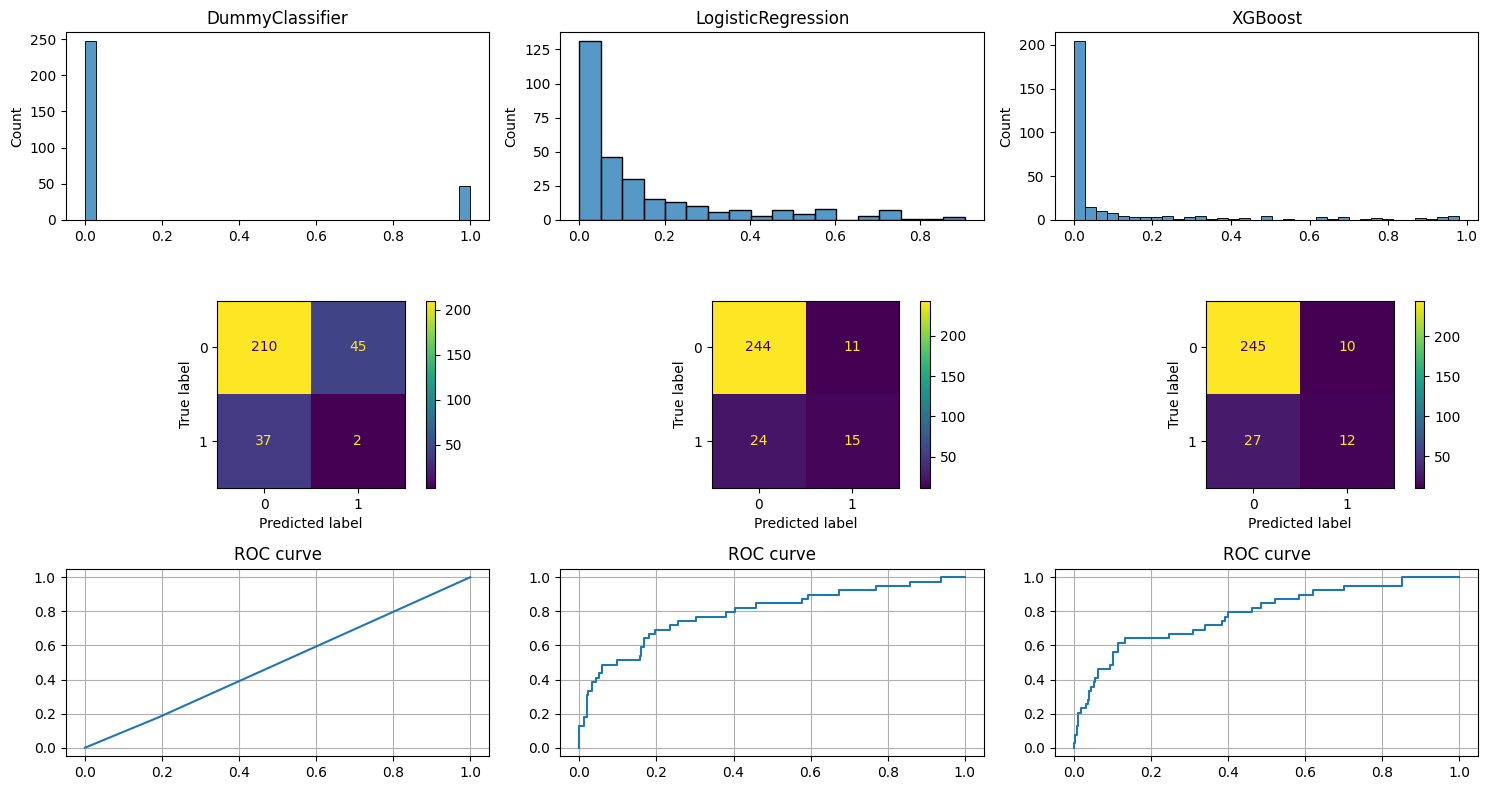

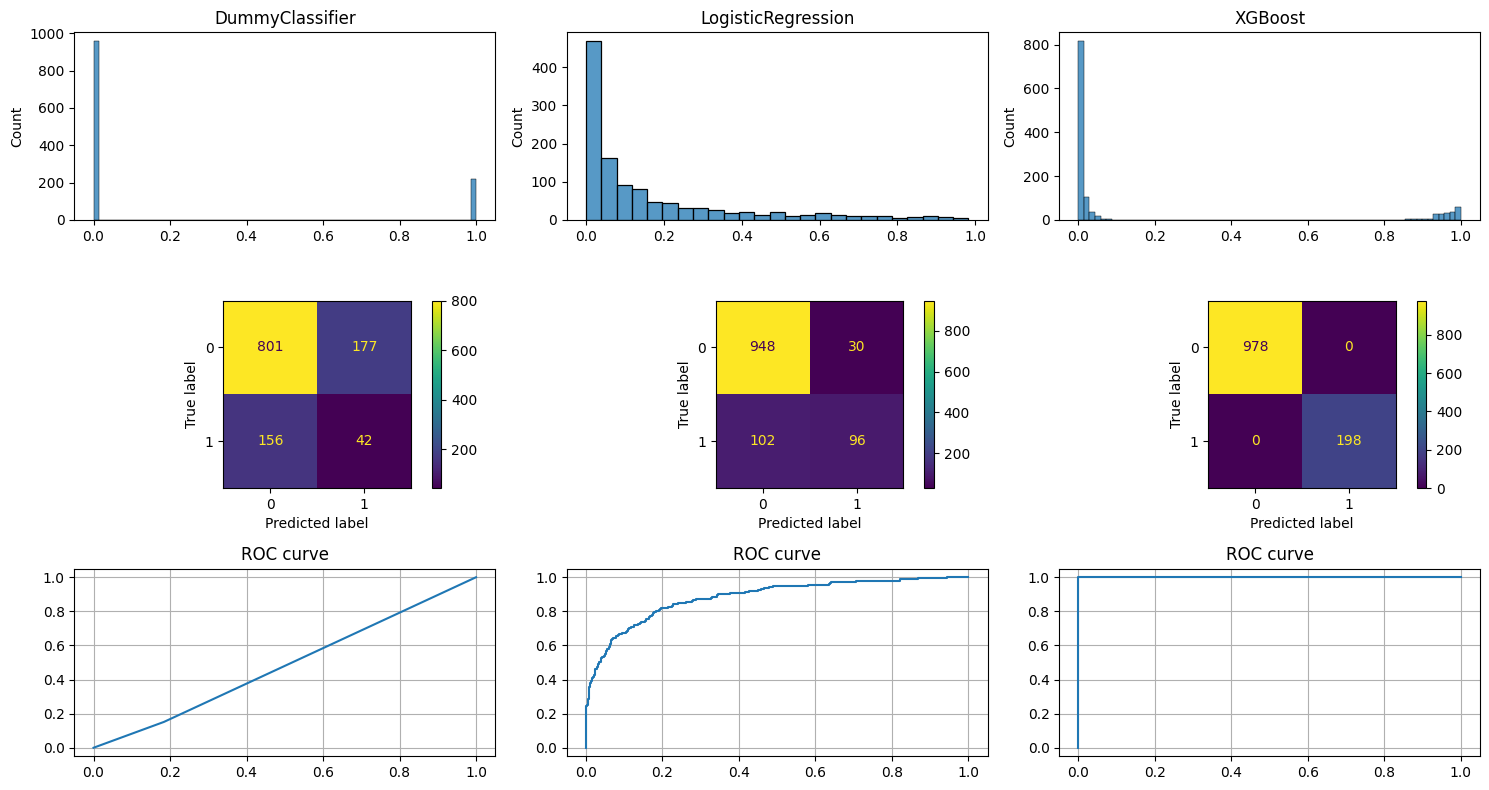

In [79]:
print_results(results_list, train_results_list)
display_results(results_list, train_results_list)

# PASS 2

In [80]:
# on essaie de supprimer la feature "niveau_hierarchique_poste" (fortement corrélé à "revenu_mensuel")

df.drop(columns=["niveau_hierarchique_poste"], inplace=True)

separation_train_test()

results_list = []
results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


In [81]:
train_results_list = []
train_results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams, False))
train_results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams, False))
train_results_list.append(entrainement_model("XGBoost", XGBoostParams, False))

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.759,0.136,0.154,0.145,-1.099,"[0.0, 0.0, 0.25, 0.125, 0.286]",0.132
1,LogisticRegression,0.884,0.593,0.410,0.485,-0.005,"[0.0, 0.25, 0.625, 0.0, 0.286]",0.232
2,XGBoost,0.871,0.522,0.308,0.387,-0.123,"[0.0, 0.25, 0.375, 0.25, 0.143]",0.204


,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.720,0.190,0.202,0.196,-0.998,"[0.15, 0.231, 0.154, 0.175, 0.175]",0.177
1,LogisticRegression,0.886,0.754,0.480,0.586,0.186,"[0.45, 0.385, 0.462, 0.55, 0.425]",0.454
2,XGBoost,1.000,1.000,1.000,1.000,1.000,"[0.325, 0.385, 0.436, 0.4, 0.4]",0.389


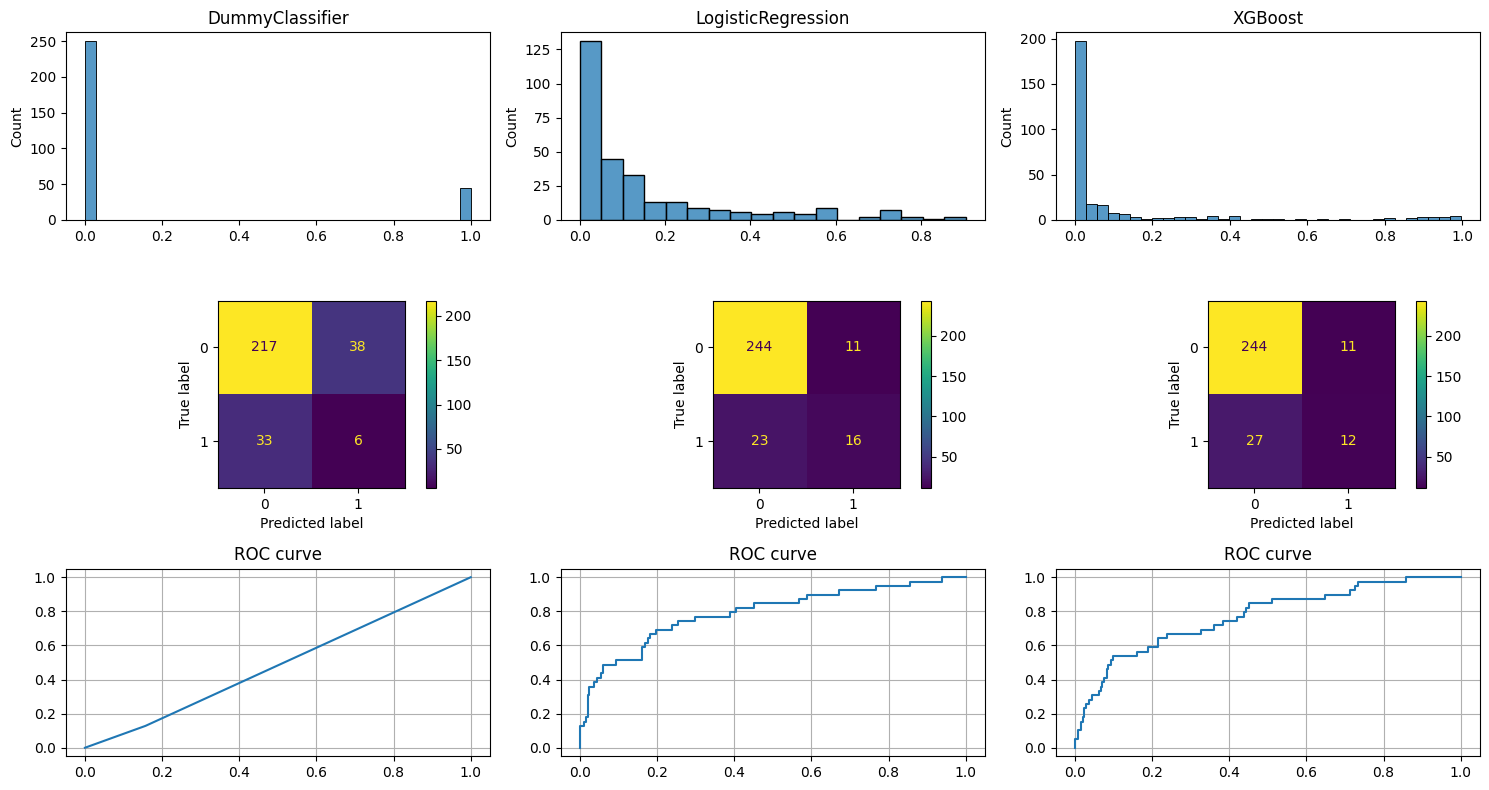

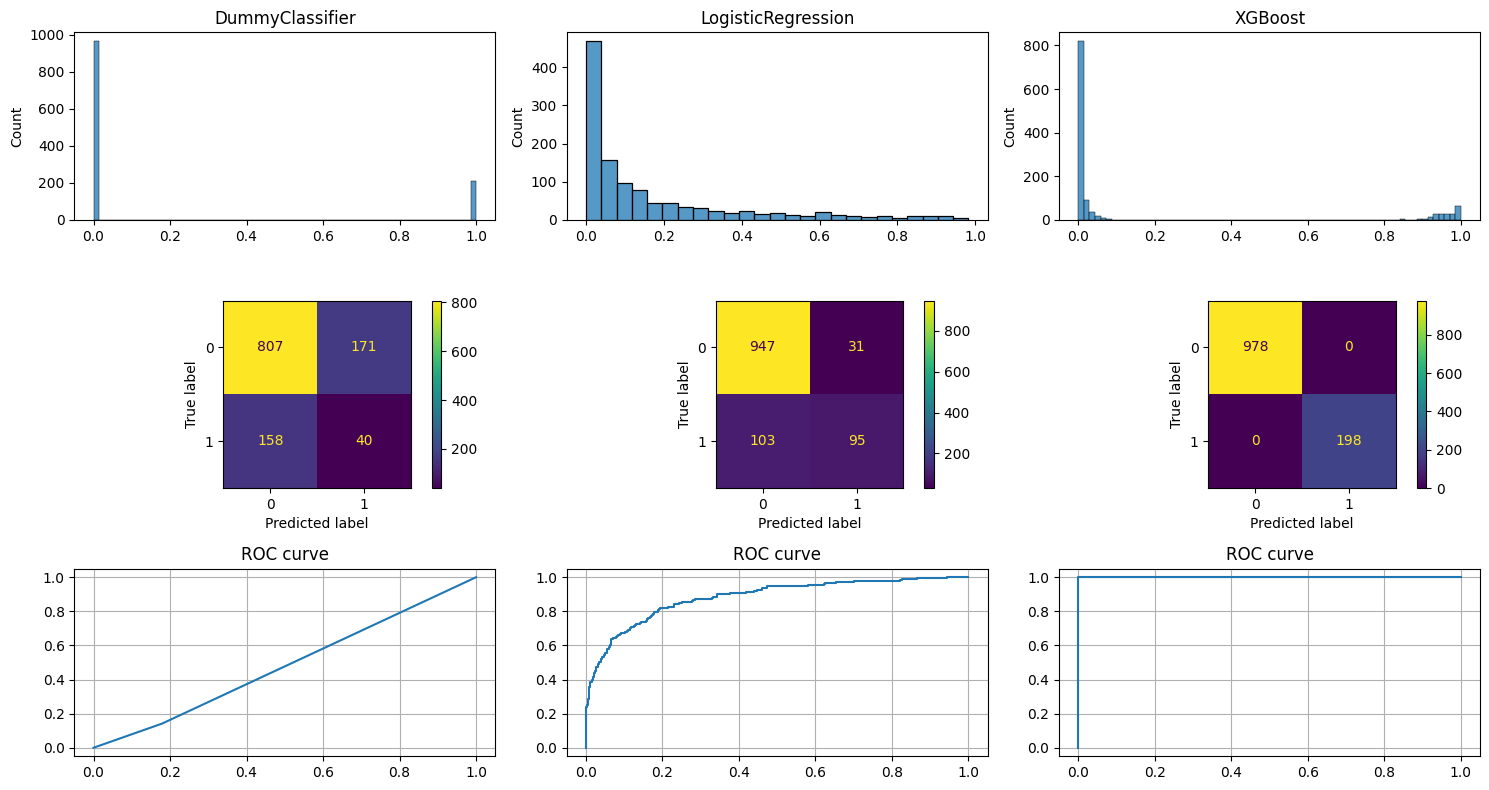

In [82]:
print_results(results_list, train_results_list)
display_results(results_list, train_results_list)

# Overfit

* Le modèle XGBoost présente un fort Sur-apprentissage sur le jeu d'entrainement F1-score 0.98 / 0.42
* Le modèle LogisticRegression est moins affecté par le Sur-apprentissage 0.48 / 0.58
* Les modèles restent meilleur que le dummy de référence


Remédiations:
* Vérifier la qualité du découpage entraînement / test => contrôler les doublons d’ID ou les chevauchements de groupes entre train et test ou split par groupe plutôt qu’un split aléatoire
* Vérifier la présence de fuite de données dans les variables explicatives => revue des features et de leur mode de calcul est souvent nécessaire, en particulier pour les agrégations
* Une complexité excessive du modèle par rapport à la quantité de données => la régularisation, la réduction de profondeur, le subsampling des lignes et des colonnes permettent de forcer une généralisation plus robuste

# Vérifie la répartition des données train/test

In [83]:
df["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [84]:
y_train.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.831633
1    0.168367
Name: proportion, dtype: float64

In [85]:
y_test.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.867347
1    0.132653
Name: proportion, dtype: float64

La répartition true / false est plutot bien répartie

# PASS 3

# amélioration du modèle

In [86]:
RandomForestClassifierParams["class_weight"] = "balanced"

nb_pos = (df["a_quitte_l_entreprise"] == True).sum()
nb_neg = (df["a_quitte_l_entreprise"] == False).sum()
XGBoostParams["scale_pos_weight"] = nb_neg / nb_pos
print(nb_pos, nb_neg, XGBoostParams["scale_pos_weight"])

results_list = []
results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

237 1233 5.2025316455696204


In [87]:
train_results_list = []
train_results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams, False))
train_results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams, False))
train_results_list.append(entrainement_model("XGBoost", XGBoostParams, False))

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.721,0.136,0.205,0.163,-1.424,"[0.0, 0.0, 0.0, 0.25, 0.0]",0.050
1,LogisticRegression,0.884,0.593,0.410,0.485,-0.005,"[0.0, 0.25, 0.625, 0.0, 0.286]",0.232
2,XGBoost,0.867,0.500,0.385,0.435,-0.153,"[0.0, 0.375, 0.375, 0.25, 0.143]",0.229


,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.714,0.165,0.172,0.168,-1.041,"[0.175, 0.103, 0.154, 0.075, 0.125]",0.126
1,LogisticRegression,0.886,0.754,0.480,0.586,0.186,"[0.45, 0.385, 0.462, 0.55, 0.425]",0.454
2,XGBoost,1.000,1.000,1.000,1.000,1.000,"[0.375, 0.41, 0.487, 0.475, 0.45]",0.439


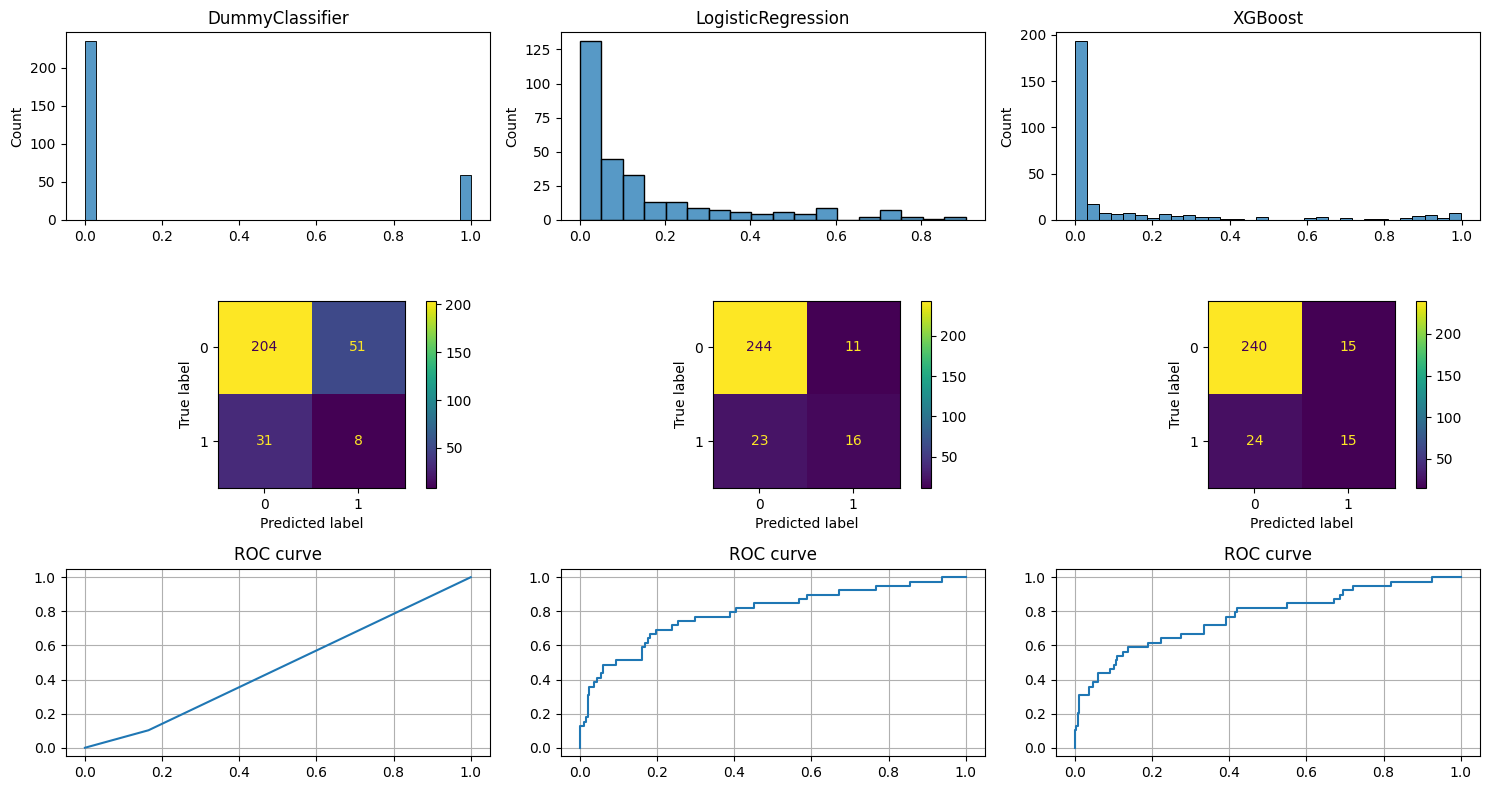

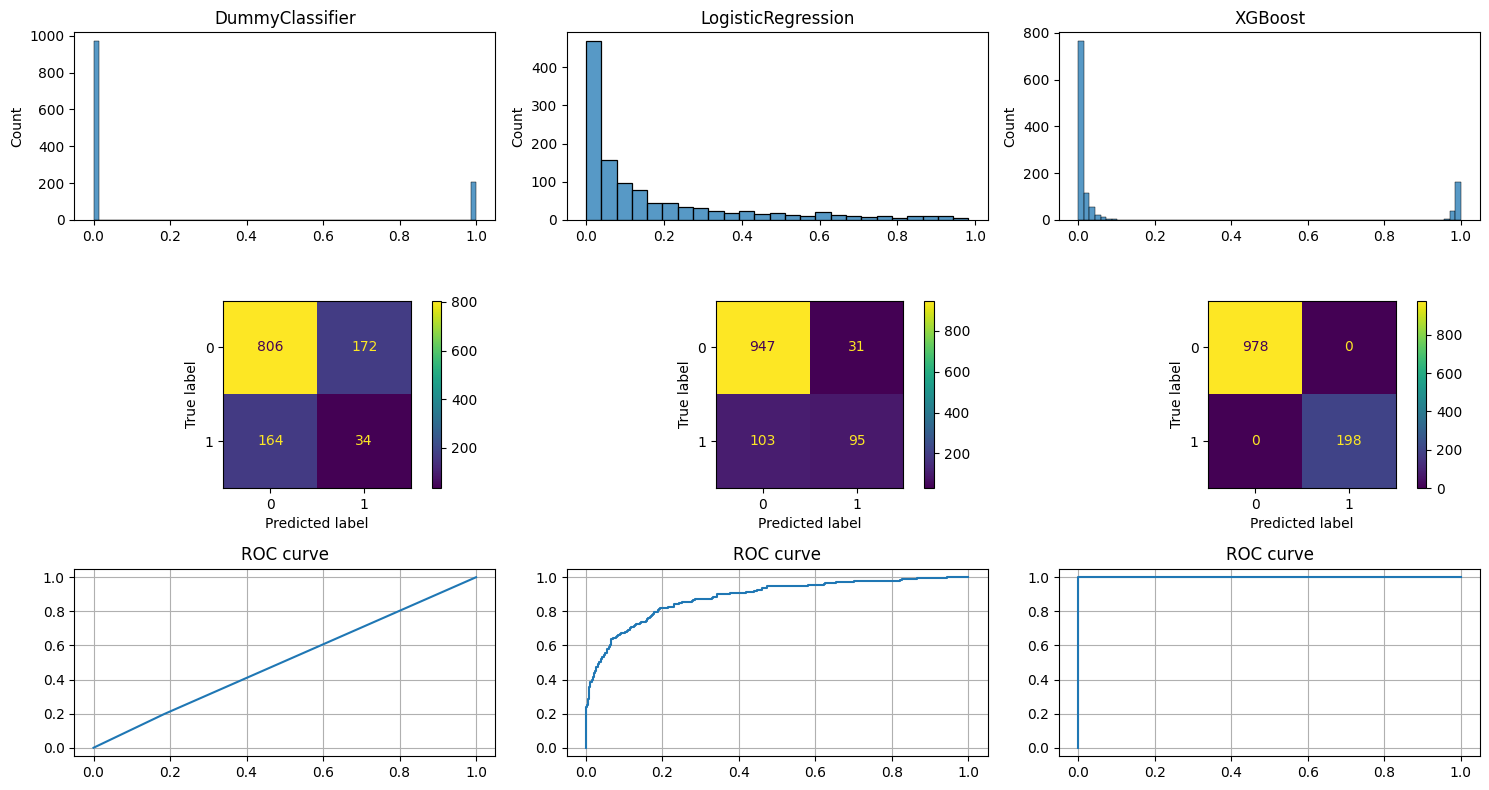

In [88]:
print_results(results_list, train_results_list)
display_results(results_list, train_results_list)

# PASS 4

In [ ]:
pass_4 = False

In [90]:
if pass_4:

    df["pression_travail"] = df["heure_supplementaires"] * df["frequence_deplacement"]

    df["insatisfaction_globale"] = (
        df["satisfaction_employee_nature_travail"] +
        df["satisfaction_employee_equipe"] +
        df["satisfaction_employee_equilibre_pro_perso"]
    )

    df.drop(columns=["satisfaction_employee_nature_travail"], inplace=True)
    df.drop(columns=["satisfaction_employee_equipe"], inplace=True)
    df.drop(columns=["satisfaction_employee_equilibre_pro_perso"], inplace=True)
    df.drop(columns=["heure_supplementaires"], inplace=True)
    df.drop(columns=["frequence_deplacement"], inplace=True)

    # séparation train/test
    separation_train_test()

    results_list = []
    results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
    results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
    results_list.append(entrainement_model("XGBoost", XGBoostParams))

pass_list.append(results_list)

Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


In [91]:
if pass_4:

    train_results_list = []
    train_results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams, False))
    train_results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams, False))
    train_results_list.append(entrainement_model("XGBoost", XGBoostParams, False))

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.776,0.171,0.179,0.175,-0.951,"[0.125, 0.25, 0.25, 0.0, 0.143]",0.154
1,LogisticRegression,0.878,0.560,0.359,0.438,-0.064,"[0.0, 0.375, 0.625, 0.0, 0.286]",0.257
2,XGBoost,0.847,0.400,0.308,0.348,-0.330,"[0.125, 0.375, 0.375, 0.0, 0.143]",0.204


,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.722,0.182,0.187,0.185,-0.986,"[0.3, 0.128, 0.103, 0.25, 0.25]",0.206
1,LogisticRegression,0.877,0.723,0.434,0.543,0.119,"[0.375, 0.359, 0.359, 0.425, 0.475]",0.399
2,XGBoost,1.000,1.000,1.000,1.000,1.000,"[0.275, 0.462, 0.436, 0.45, 0.525]",0.429


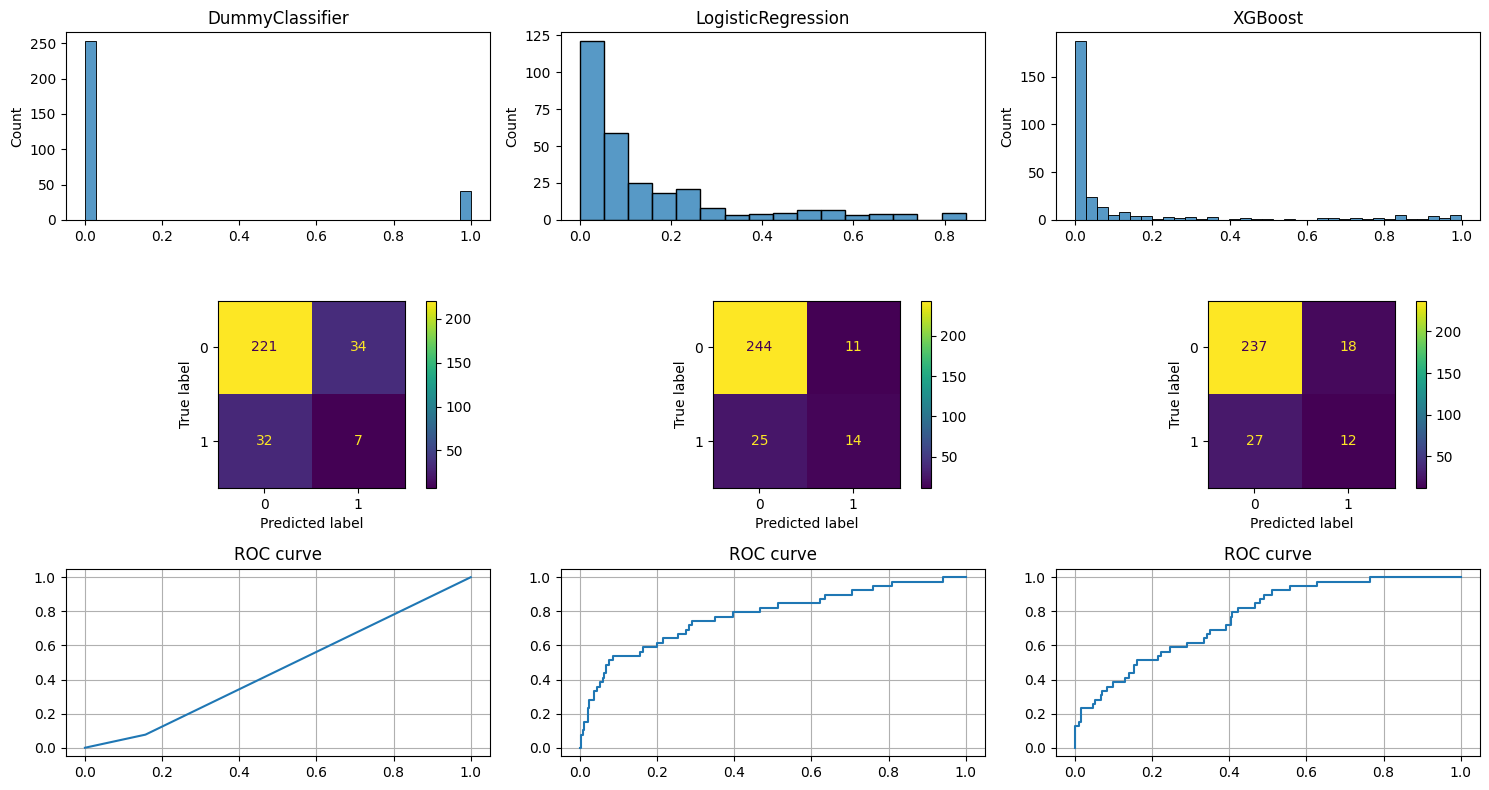

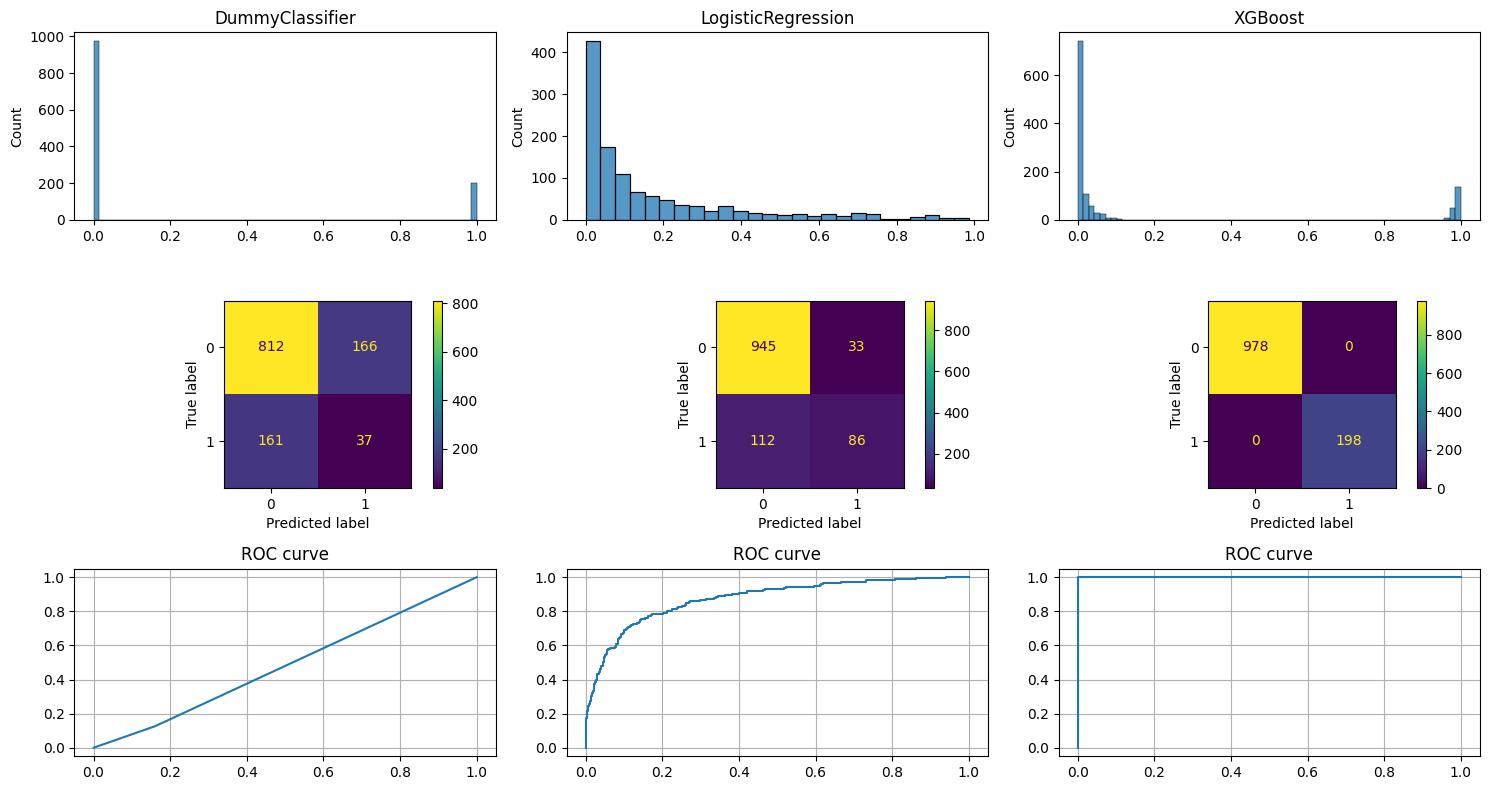

In [92]:
if pass_4:

    print_results(results_list, train_results_list)
    display_results(results_list, train_results_list)

# PASS 5

# recherche du meilleur seuil (XGBoost)

In [93]:
best_t, best_f1, best_recall = 0, 0, 0

for t in range(1, 9, 1):
    threshold = 0.1 * t
    results_list = []
    results_list.append(entrainement_model("XGBoost", XGBoostParams))

    f1 = results_list[0]["f1"]
#    recall = results_list[0]["recall"]

    if f1 > best_f1:
        best_f1 = f1
        best_t = threshold

#    if recall > best_recall:
#        best_recall = recall
#        best_t = threshold

print("Best threshold:", best_t)
print("Best F1:", best_f1)
print("Best Recall:", best_recall)

threshold = best_t

Best threshold: 0.1
Best F1: 0.3883495145631068
Best Recall: 0


In [94]:
results_list = []
results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.728,0.113,0.154,0.130,-1.365,"[0.25, 0.375, 0.125, 0.0, 0.0]",0.150
1,LogisticRegression,0.663,0.246,0.744,0.369,-1.927,"[0.0, 0.375, 0.625, 0.0, 0.286]",0.257
2,XGBoost,0.786,0.312,0.513,0.388,-0.862,"[0.125, 0.375, 0.375, 0.0, 0.143]",0.204


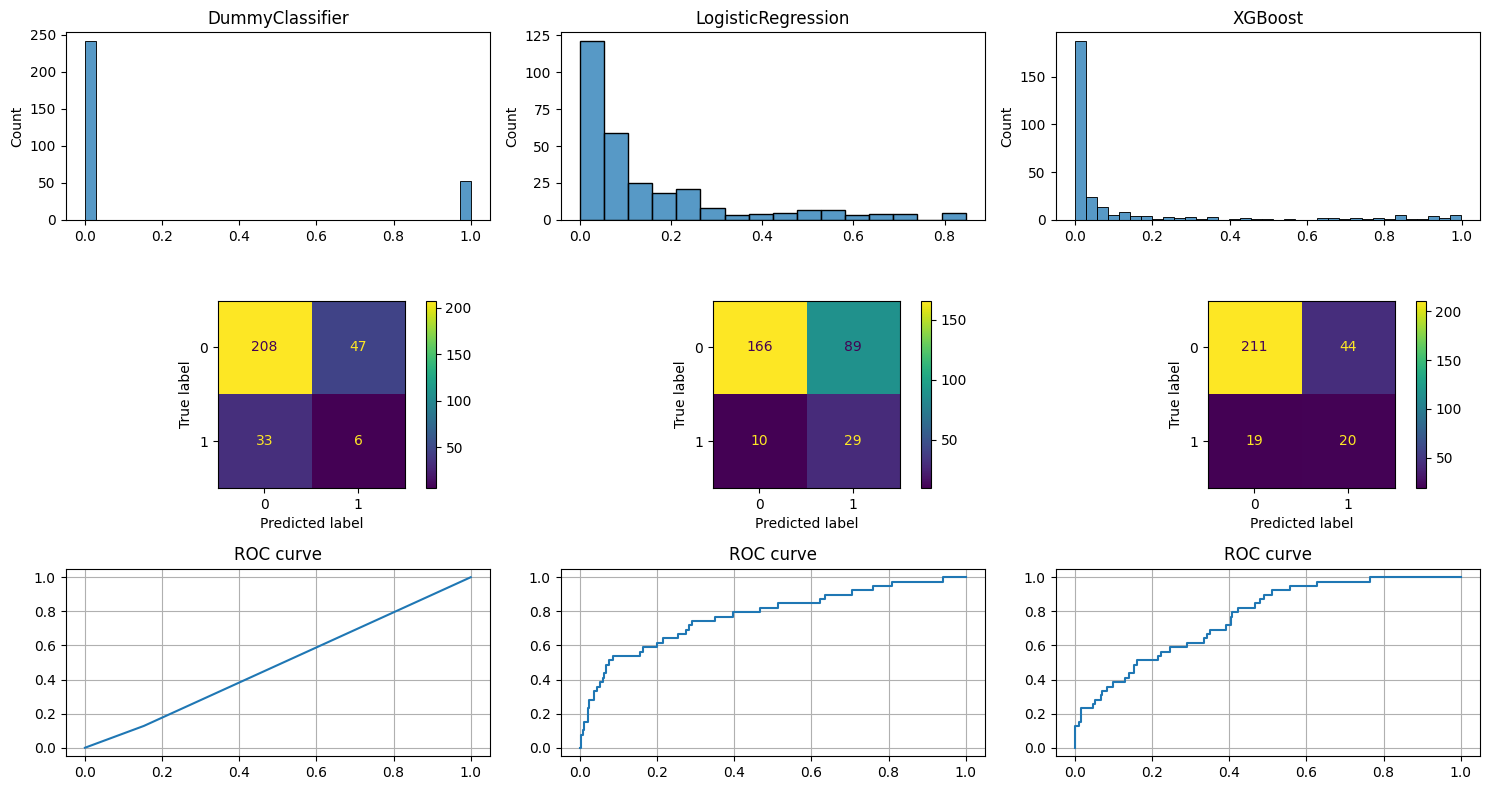

In [95]:
print_results(results_list)
display_results(results_list)

In [96]:
# optimisation des hyperparamètres

# Affiche un graphique de l'évolution du F1-score

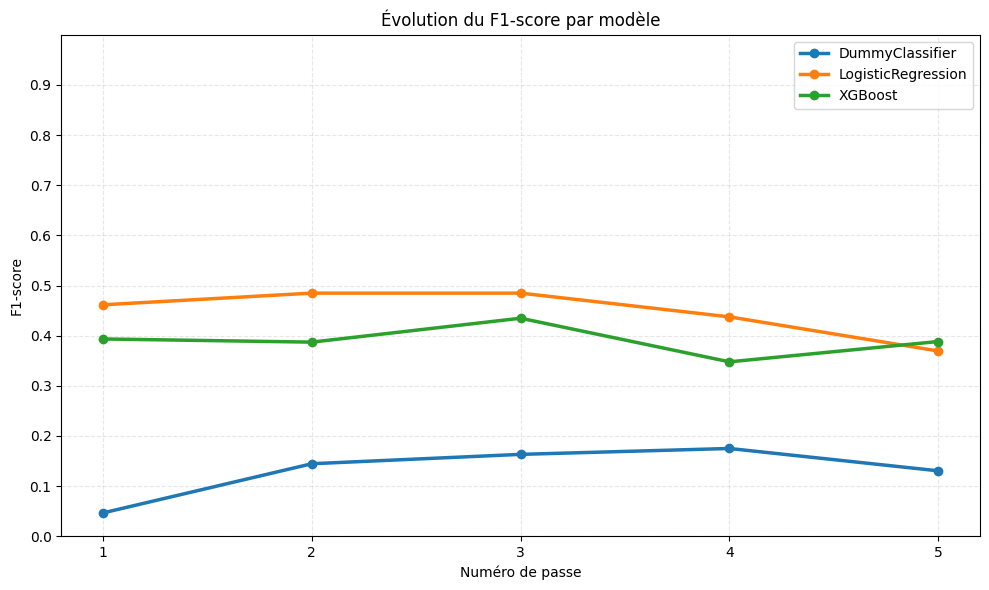

In [103]:
import matplotlib.pyplot as plt
import numpy as np

# noms des modèles (pris sur la première passe)
models = [r["model"] for r in pass_list[0]]

# construction matrice : lignes = passes, colonnes = modèles
data = np.empty((len(pass_list), len(models)))

j = 0
for results_list in pass_list:
    i = 0
    for results in results_list:
        data[j, i] = results["f1"]
        i += 1
    j += 1


# PLOT
fig, ax = plt.subplots(figsize=(10, 6))

x = range(1, len(pass_list)+1, 1)  # numéro de passe

i = 0
for model in models:

    f1_scores = data[:, i]

    ax.plot(
        x,
        f1_scores,
        marker='o',
        linewidth=2.5,
        label=model
    )

    i += 1

ax.set_ylim(0, 1)
ax.set_title("Évolution du F1-score par modèle")
ax.set_xlabel("Numéro de passe")
ax.set_ylabel("F1-score")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()


plt.xticks(x)
plt.yticks(np.arange(0, 1, 0.1))
plt.tight_layout()
plt.show()

In [98]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,int64
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,annees_depuis_la_derniere_promotion,int64
6,annes_sous_responsable_actuel,int64
7,age,int64
8,revenu_mensuel,int64
9,nombre_experiences_precedentes,int64


# Prédictions sur de nouvelles données

# Export

In [99]:
df.to_parquet("model.parquet")